# Spatial regression

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import itertools
import os
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import json
import shutil
import urllib.request
import pandas as pd
from scipy.linalg import eigvalsh


# Install pre-built CmdStan binary
# (faster than compiling from source via install_cmdstan() function)
tgz_file = 'colab-cmdstan-2.36.0.tar.gz'
tgz_url = 'https://github.com/stan-dev/cmdstan/releases/download/v2.36.0/colab-cmdstan-2.36.0.tgz'
if not os.path.exists(tgz_file):
    urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file)

# Specify CmdStan location via environment variable
os.environ['CMDSTAN'] = './cmdstan-2.36.0'
# Check CmdStan path
from cmdstanpy import CmdStanModel, cmdstan_path
cmdstan_path()

'cmdstan-2.36.0'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/updated_data_v2.geojson"
df = gpd.read_file(DATA_PATH)

In [ ]:
selected_cov = ['fem_house_rate', 'fertility_rate','young_neet']
ecec_cov = ['ecec_participation',
            'coverage',
            'per_capita_public_expenditure',
           # 'per_capita_user_contribution',
           # 'other_percapita_user_contrib',
           # 'ecec_diffusion'
            ]

selected_cov = selected_cov + ecec_cov

In [ ]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

X = df[selected_cov].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

N = 107
P = len(selected_cov)

In [ ]:
import libpysal
w = libpysal.weights.Queen.from_dataframe(df)
W_mat = w.full()[0]

node1, node2 = np.where(np.triu(W_mat, 1) == 1)  # edges once
node1 = node1 + 1  # Stan 1-based
node2 = node2 + 1

n_neighbors = W_mat.sum(axis=1).astype(float)

L = np.diag(n_neighbors) - W_mat
lambda_eig = np.linalg.eigvalsh(L).astype(float)


In [ ]:
spatial_model = """
functions {
  real sparse_car_leroux_lpdf(
    vector phi,
    real tau2,                  // NOTE: used as PRECISION in this parameterization
    real rho,
    array[] int node1,
    array[] int node2,
    vector n_neighbors,         // degree vector: d_i
    vector lambda,              // eigenvalues of (D - W)
    int N,
    int N_edges
  ) {
    real phi_W_phi = 0;
    real phi_D_phi = 0;
    real phi_phi = dot_product(phi, phi);
    real quad;
    real log_det = 0;

    // sum over edges: \sum_{(i,j) in E} phi_i * phi_j
    for (e in 1:N_edges) {
      phi_W_phi += phi[node1[e]] * phi[node2[e]];
    }
    // convert edge sum to full symmetric quadratic contribution (W is symmetric)
    phi_W_phi *= 2;

    // phi' D phi = \sum_i d_i * phi_i^2
    phi_D_phi = dot_product(n_neighbors, phi .* phi);

    // Leroux quadratic form
    quad = rho * (phi_D_phi - phi_W_phi) + (1 - rho) * phi_phi;

    // log determinant using eigenvalues of (D - W):
    // | rho (D-W) + (1-rho) I | = \prod_i (rho*lambda_i + (1-rho))
    for (i in 1:N) {
      log_det += log(rho * lambda[i] + (1 - rho));
    }

    // log density up to the normalizing constant
    return 0.5 * (N * log(tau2) + log_det - tau2 * quad);
  }
}

data {
  int<lower=1> N;
  int<lower=1> P;
  int<lower=1> N_edges;

  vector[N] y_star;
  matrix[N, P] X_star;

  array[N_edges] int<lower=1, upper=N> node1;
  array[N_edges] int<lower=1, upper=N> node2;
  vector[N] n_neighbors;   // degrees d_i
  vector[N] lambda;        // eigenvalues of (D - W)
}

parameters {
  real alpha;
  vector[P] beta;

  real<lower=1e-6> sigma;
  real<lower=1e-6> tau2;                // precision-like in the lpdf above
  vector[N] phi_raw;
  real<lower=0, upper=0.95> rho;
}

transformed parameters {
  vector[N] phi = phi_raw - mean(phi_raw);
}

model {
  // Priors (keep yours)
  tau2  ~ inv_gamma(2, 1);
  rho   ~ beta(1, 1);
  sigma ~ inv_gamma(2, 1);

  alpha ~ normal(0, 2);
  beta  ~ normal(0, 1);

  // Sparse Leroux CAR prior
  phi_raw ~ sparse_car_leroux(tau2, rho, node1, node2, n_neighbors, lambda, N, N_edges);

  // Likelihood
  y_star ~ normal(alpha + X_star * beta + phi, sigma);
}

"""

In [ ]:
with open("final_spatial_model.stan", "w") as f:
    f.write(spatial_model)

In [ ]:
stan_data = {
    "N": int(N),
    "P": int(P),
    "N_edges": int(len(node1)),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "node1": node1.astype(int),
    "node2": node2.astype(int),
    "n_neighbors": n_neighbors.astype(float),
    "lambda": lambda_eig.astype(float),
}

In [ ]:
model_exe = CmdStanModel(stan_file="final_spatial_model.stan")

In [43]:
fit = model_exe.sample(
    data=stan_data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.99,
    max_treedepth=15
)

chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

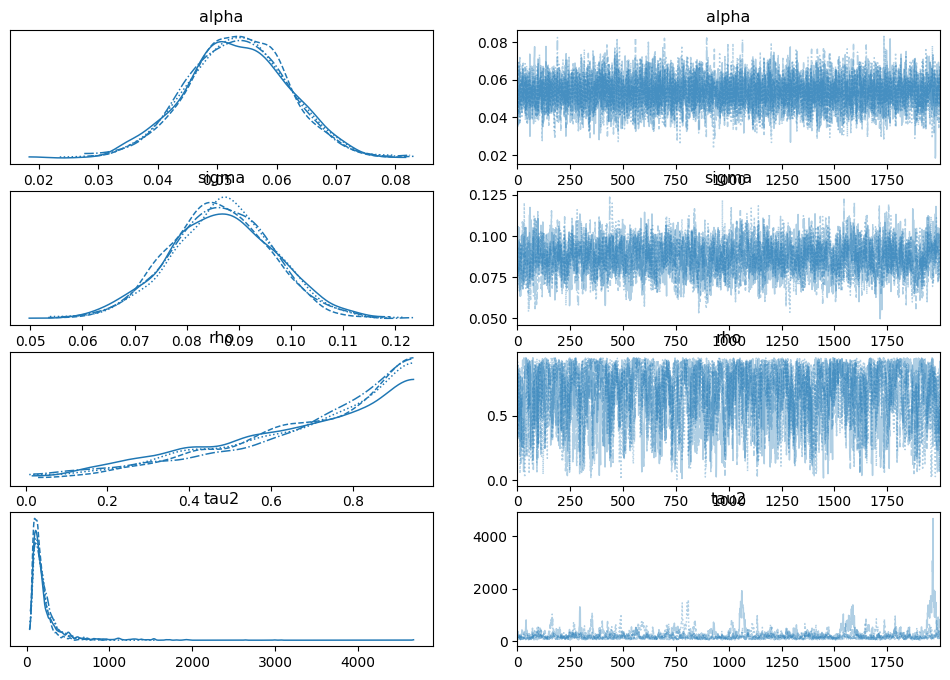

In [44]:

feature_names = list(selected_cov)   # length P

idata = az.from_cmdstanpy(
    posterior=fit,
    coords={"feature": feature_names},
    dims={"beta": ["feature"]},
)
az.summary(idata, var_names=["alpha","sigma","rho","tau2","beta"], hdi_prob=0.9)
az.plot_trace(idata, var_names=["alpha","sigma","rho","tau2"]);

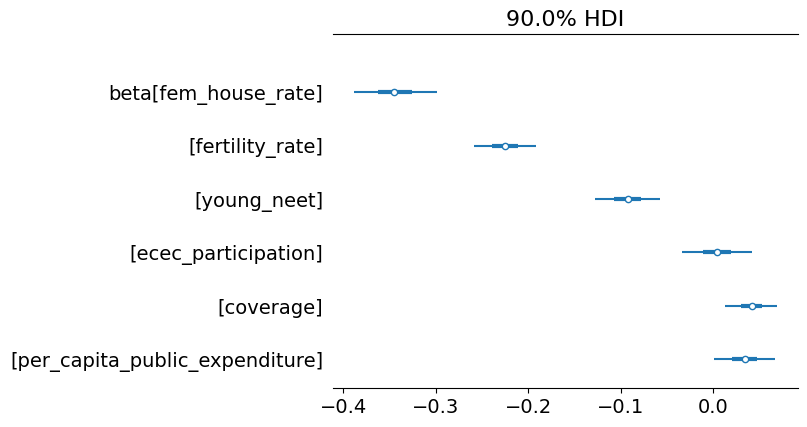

In [45]:
az.plot_forest(idata, var_names=["beta"], hdi_prob=0.9, combined=True);


In [46]:
az.summary(idata, var_names=["alpha","sigma","rho","tau2","beta"], hdi_prob=0.9)


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.053,0.008,0.039,0.067,0.000,0.000,7507.0,5679.0,1.00
sigma,0.087,0.010,0.070,0.103,0.000,0.000,897.0,2129.0,1.00
rho,0.680,0.218,0.350,0.950,0.009,0.004,557.0,1898.0,1.00
tau2,200.395,182.225,48.304,355.537,12.909,53.764,356.0,340.0,1.02
beta[fem_house_rate],-0.344,0.028,-0.388,-0.298,0.001,0.000,1059.0,1976.0,1.00
beta[fertility_rate],-0.225,0.021,-0.258,-0.191,0.001,0.000,1075.0,2024.0,1.00
beta[young_neet],-0.093,0.022,-0.128,-0.057,0.000,0.000,3666.0,5218.0,1.00
beta[ecec_participation],0.004,0.023,-0.034,0.042,0.000,0.000,2947.0,4441.0,1.00
beta[coverage],0.042,0.017,0.013,0.069,0.000,0.000,2194.0,5080.0,1.00
beta[per_capita_public_expenditure],0.034,0.020,0.001,0.067,0.000,0.000,3385.0,5170.0,1.00


In [48]:
summary_df = az.summary(
    idata,
    var_names=["alpha", "sigma", "rho", "tau2", "beta"],
    hdi_prob=0.9
)

summary_df.to_latex(
    "posterior_summary.tex",
    float_format="%.3f",
    caption="Posterior summary statistics (90\\% credible intervals)",
    label="tab:posterior_summary"
)


In [49]:
cols = ["mean", "sd", "hdi_5%", "hdi_95%", "r_hat"]

summary_df[cols].to_latex(
    "posterior_summary.tex",
    float_format="%.3f",
    caption="Posterior means and 90\\% credible intervals",
    label="tab:posterior_summary"
)

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -0.344  0.028  -0.396   -0.293      0.001    0.000    1059.0   
beta[1]  -0.225  0.021  -0.262   -0.184      0.001    0.000    1075.0   
beta[2]  -0.093  0.022  -0.135   -0.053      0.000    0.000    3666.0   
beta[3]   0.004  0.023  -0.037    0.050      0.000    0.000    2947.0   
beta[4]   0.042  0.017   0.009    0.073      0.000    0.000    2194.0   
...         ...    ...     ...      ...        ...      ...       ...   
phi[103]  0.056  0.047  -0.029    0.146      0.001    0.001    1403.0   
phi[104] -0.077  0.066  -0.201    0.045      0.002    0.001    1067.0   
phi[105]  0.022  0.059  -0.096    0.133      0.002    0.001    1156.0   
phi[106]  0.002  0.046  -0.084    0.091      0.001    0.001    5732.0   
rho       0.680  0.218   0.273    0.950      0.009    0.004     557.0   

          ess_tail  r_hat  
beta[0]     1976.0    1.0  
beta[1]     2024.0    1.0  
beta[2]     5218.0    1.0  
beta[3]    

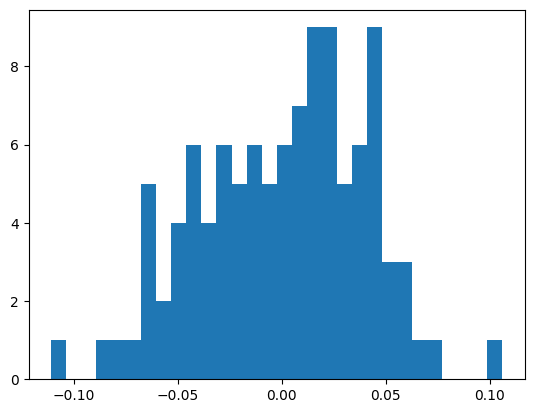

In [50]:
summary_beta_90 = az.summary(fit, var_names=["beta", "phi", "rho"])
print(summary_beta_90)
phi_mean = summary_beta_90.loc[summary_beta_90.index.str.startswith("phi"), "mean"].values
plt.hist(phi_mean, bins=30)

betas_mean = summary_beta_90.loc[summary_beta_90.index.str.startswith("beta"), "mean"].values

<Figure size 800x600 with 0 Axes>

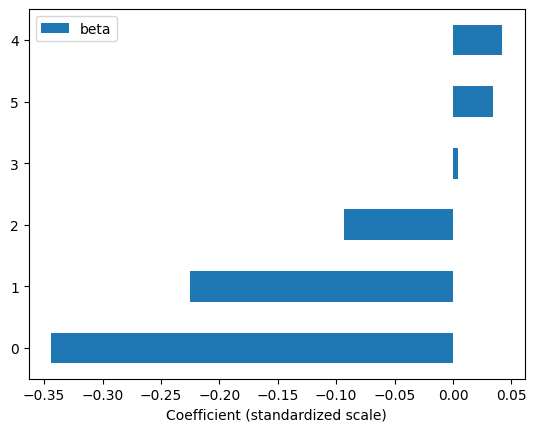

In [51]:
plt.figure(figsize=(8,6))
pd.DataFrame(betas_mean, columns=['beta']).sort_values(by='beta').plot(kind='barh')
plt.xlabel('Coefficient (standardized scale)')
plt.show()